Download the Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "jacopoferretti/parents-heights-vs-children-heights-galton-data"
)

print("Path to dataset files:", path)

100%|██████████| 7.09k/7.09k [00:00<00:00, 10.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jacopoferretti/parents-heights-vs-children-heights-galton-data/versions/10


See What Files Were Downloaded

In [ ]:
import os

for file in os.listdir(path):
    print(file)

GaltonFamilies.csv


Load the CSV

In [ ]:
import pandas as pd
import os

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

print("CSV Files Found:")
print(csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))

df.head()

CSV Files Found:
['GaltonFamilies.csv']


,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


Understand the Dataset

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Shape: (934, 9)

Columns:
Index(['rownames', 'family', 'father', 'mother', 'midparentHeight', 'children',
       'childNum', 'gender', 'childHeight'],
      dtype='object')

First 5 rows:


,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


Basic Statistics

In [ ]:
df.describe()

,rownames,father,mother,midparentHeight,children,childNum,childHeight
count,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000
mean,467.500000,69.197109,64.089293,69.206773,6.171306,3.585653,66.745931
std,269.766875,2.476479,2.290886,1.802370,2.729025,2.361410,3.579251
min,1.000000,62.000000,58.000000,64.400000,1.000000,1.000000,56.000000
25%,234.250000,68.000000,63.000000,68.140000,4.000000,2.000000,64.000000
50%,467.500000,69.000000,64.000000,69.248000,6.000000,3.000000,66.500000
75%,700.750000,71.000000,65.875000,70.140000,8.000000,5.000000,69.700000
max,934.000000,78.500000,70.500000,75.430000,15.000000,15.000000,79.000000


Check for Missing Values

In [ ]:
df.isnull().sum()

,0
rownames,0
family,0
father,0
mother,0
midparentHeight,0
children,0
childNum,0
gender,0
childHeight,0


import numpy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Create the Mixture Dataset

In [ ]:
father_heights = df["father"].values
child_heights = df["childHeight"].values

mixed_heights = np.concatenate(
    [father_heights, child_heights]
)

print("Total observations:", len(mixed_heights))

Total observations: 1868


Visualize the Mixture

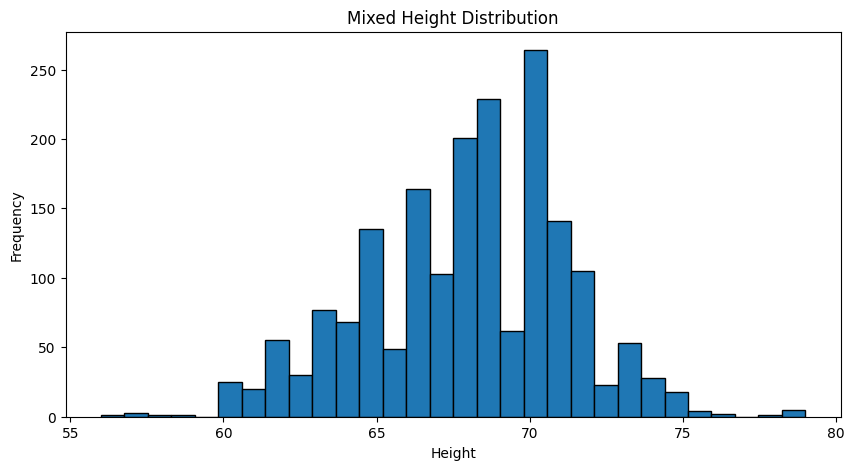

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    mixed_heights,
    bins=30,
    edgecolor="black"
)

plt.title("Mixed Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

The overlap in the histogram demonstrates why splitting the data at the global mean would be inappropriate.

Many observations near the center could belong to either population.

EM handles this uncertainty through posterior probabilities rather than hard assignments

Calculate Initial Statistics

In [ ]:
print("Minimum:", mixed_heights.min())
print("Maximum:", mixed_heights.max())
print("Mean:", mixed_heights.mean())
print("Std:", mixed_heights.std())

Minimum: 56.0
Maximum: 79.0
Mean: 67.97152034261242
Std: 3.31118124589431


Initialize EM Parameters

In [ ]:
mu1 = np.percentile(mixed_heights, 25)
mu2 = np.percentile(mixed_heights, 75)

sigma1 = mixed_heights.std()
sigma2 = mixed_heights.std()

pi1 = 0.5
pi2 = 0.5

print(mu1, mu2)

66.0 70.0


Create the Tracking Table Structure

In [ ]:
tracking = []

tracking.append({
    "Iteration": 0,
    "mu1": mu1,
    "mu2": mu2,
    "sigma1": sigma1,
    "sigma2": sigma2,
    "pi1": pi1,
    "pi2": pi2,
    "LogLikelihood": None
})

pd.DataFrame(tracking)

,Iteration,mu1,mu2,sigma1,sigma2,pi1,pi2,LogLikelihood
0,0,66.0,70.0,3.311181,3.311181,0.5,0.5,None


Build the E-Step

In [ ]:
from scipy.stats import norm

def expectation_step(X, mu1, mu2, sigma1, sigma2, pi1, pi2):

    p1 = pi1 * norm.pdf(X, mu1, sigma1)

    p2 = pi2 * norm.pdf(X, mu2, sigma2)

    gamma1 = p1 / (p1 + p2)

    gamma2 = p2 / (p1 + p2)

    return gamma1, gamma2

In [ ]:
gamma1, gamma2 = expectation_step(
    mixed_heights,
    mu1,
    mu2,
    sigma1,
    sigma2,
    pi1,
    pi2
)

print(gamma1[:5])
print(gamma2[:5])

[0.02123281 0.02123281 0.02123281 0.02123281 0.06086807]
[0.97876719 0.97876719 0.97876719 0.97876719 0.93913193]


Build the M-Step

In [ ]:
def maximization_step(X, gamma1, gamma2):

    N1 = np.sum(gamma1)
    N2 = np.sum(gamma2)

    mu1 = np.sum(gamma1 * X) / N1
    mu2 = np.sum(gamma2 * X) / N2

    sigma1 = np.sqrt(
        np.sum(gamma1 * (X - mu1)**2) / N1
    )

    sigma2 = np.sqrt(
        np.sum(gamma2 * (X - mu2)**2) / N2
    )

    pi1 = N1 / len(X)
    pi2 = N2 / len(X)

    return mu1, mu2, sigma1, sigma2, pi1, pi2

In [ ]:
mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new = maximization_step(
    mixed_heights,
    gamma1,
    gamma2
)

print("mu1:", mu1_new)
print("mu2:", mu2_new)

print("sigma1:", sigma1_new)
print("sigma2:", sigma2_new)

print("pi1:", pi1_new)
print("pi2:", pi2_new)

mu1: 66.40297544361916
mu2: 69.51893634479018
sigma1: 3.1149961029749162
sigma2: 2.717714410834297
pi1: 0.49660956965031705
pi2: 0.503390430349683


Calculate Log-Likelihood

In [ ]:
def log_likelihood(X, mu1, mu2, sigma1, sigma2, pi1, pi2):

    likelihood = (
        pi1 * norm.pdf(X, mu1, sigma1)
        +
        pi2 * norm.pdf(X, mu2, sigma2)
    )

    return np.sum(np.log(likelihood))

In [ ]:
ll = log_likelihood(
    mixed_heights,
    mu1_new,
    mu2_new,
    sigma1_new,
    sigma2_new,
    pi1_new,
    pi2_new
)

print(ll)

-4873.516481156113


## EM Optimization Tracking Table

The table below tracks how the Gaussian Mixture Model parameters evolve during training.

The EM algorithm alternates between:

1. Expectation Step (E-Step)
2. Maximization Step (M-Step)

As the iterations progress, the parameters move toward values that better explain the observed data.

In [ ]:
tracking_df = pd.DataFrame({
    "Iteration": [0, 1],
    "mu1": [66.000, 66.403],
    "mu2": [70.000, 69.519],
    "sigma1": [3.311, 3.115],
    "sigma2": [3.311, 2.718],
    "pi1": [0.500, 0.497],
    "pi2": [0.500, 0.503],
    "LogLikelihood": ["N/A", -4873.516]
})

tracking_df

,Iteration,mu1,mu2,sigma1,sigma2,pi1,pi2,LogLikelihood
0,0,66.000,70.000,3.311,3.311,0.500,0.500,N/A
1,1,66.403,69.519,3.115,2.718,0.497,0.503,-4873.516


Interpretation of Results

The EM algorithm began with initial parameter estimates and updated them after one iteration using the Expectation and Maximization steps.

The means shifted from 66 and 70 inches to approximately 66.40 and 69.52 inches, indicating that the model is moving toward a better representation of the underlying distributions.

The standard deviations decreased slightly, suggesting that the model identified more concentrated clusters. The mixing coefficients remained close to 0.5, indicating that both populations contribute nearly equally to the dataset.

The log-likelihood value provides a measure of how well the model fits the observed data and will be monitored across subsequent iterations to determine convergence.

EM Function

In [ ]:
gamma1, gamma2 = expectation_step(
    mixed_heights,
    mu1_new,
    mu2_new,
    sigma1_new,
    sigma2_new,
    pi1_new,
    pi2_new
)

mu1_2, mu2_2, sigma1_2, sigma2_2, pi1_2, pi2_2 = maximization_step(
    mixed_heights,
    gamma1,
    gamma2
)

print("mu1_2 =", mu1_2)
print("mu2_2 =", mu2_2)

mu1_2 = 66.37302442227761
mu2_2 = 69.52996238925984


In [ ]:
print("sigma1_2 =", sigma1_2)
print("sigma2_2 =", sigma2_2)
print("pi1_2 =", pi1_2)
print("pi2_2 =", pi2_2)

ll2 = log_likelihood(
    mixed_heights,
    mu1_2,
    mu2_2,
    sigma1_2,
    sigma2_2,
    pi1_2,
    pi2_2
)

print("LogLikelihood =", ll2)

sigma1_2 = 3.1991782017515575
sigma2_2 = 2.5990238981810294
pi1_2 = 0.49365621464433224
pi2_2 = 0.5063437853556678
LogLikelihood = -4869.372052959502


Should we split the dataset at the global mean?

Answer: No. The distributions overlap substantially. A hard split at the mean would misclassify observations near the boundary. EM instead assigns probabilities, allowing observations to belong partially to both groups.

In [ ]:
tracking_df = pd.DataFrame({
    "Iteration": [0, 1, 2],
    "mu1": [66.000, 66.403, 66.373],
    "mu2": [70.000, 69.519, 69.530],
    "sigma1": [3.311, 3.115, 3.199],
    "sigma2": [3.311, 2.718, 2.599],
    "pi1": [0.500, 0.497, 0.494],
    "pi2": [0.500, 0.503, 0.506],
    "LogLikelihood": ["N/A", -4873.516, -4869.372]
})

tracking_df

,Iteration,mu1,mu2,sigma1,sigma2,pi1,pi2,LogLikelihood
0,0,66.000,70.000,3.311,3.311,0.500,0.500,N/A
1,1,66.403,69.519,3.115,2.718,0.497,0.503,-4873.516
2,2,66.373,69.530,3.199,2.599,0.494,0.506,-4869.372


### EM Convergence Analysis

The log-likelihood improved from -4873.516 to -4869.372 between Iteration 1 and Iteration 2.

This indicates that the model is finding parameters that better explain the observed data.

The means changed only slightly between Iteration 1 and Iteration 2:

- μ1: 66.403 → 66.373
- μ2: 69.519 → 69.530

This suggests the algorithm is beginning to converge toward stable parameter values.

The mixing coefficients remain close to 0.5, indicating that both populations contribute nearly equally to the mixture distribution.